In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
from utils.cub_config import Config

d:\Programas\Anaconda\envs\ia_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda:0


In [3]:
model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
test_images = [
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg",
]


Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg
Classe Predita: 62 (Prob: 0.8156)


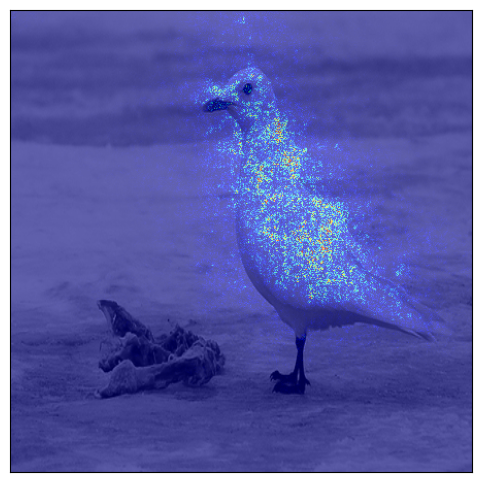

Explicação salva em: ../../out\ig_Ivory_Gull_0037_49068.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg
Classe Predita: 62 (Prob: 0.5714)


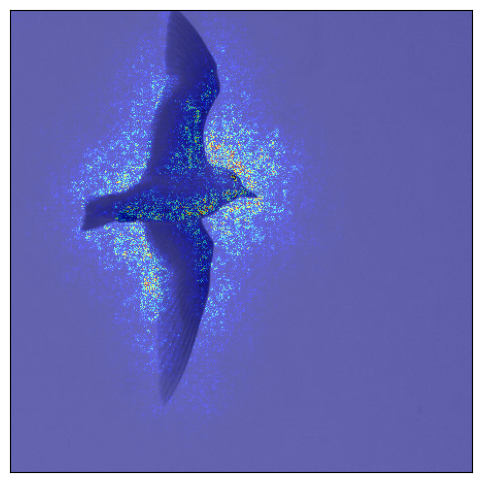

Explicação salva em: ../../out\ig_Ivory_Gull_0118_49191.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg
Classe Predita: 62 (Prob: 0.9629)


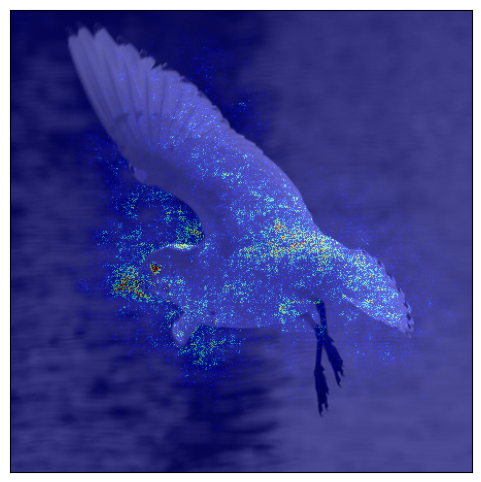

Explicação salva em: ../../out\ig_Ivory_Gull_0077_49051.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg
Classe Predita: 62 (Prob: 0.9403)


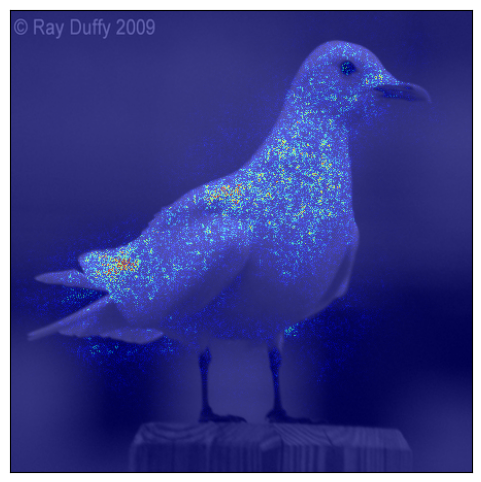

Explicação salva em: ../../out\ig_Ivory_Gull_0099_49218.jpg


In [ ]:
ig = IntegratedGradients(model)

for img_path in test_images:

    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()

    print(f"\nImagem: {img_path}")
    print(f"Classe Predita: {pred_class_idx} (Prob: {pred_class_prob:.4f})")

    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))

    img_np = np.array(image.resize((448, 448))) / 255.0


    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="absolute_value", 
        show_colorbar=False,
        use_pyplot=True,
        cmap="jet",            
        outlier_perc=2,        
        alpha_overlay=0.6      
    )
    
    # Salvar a figura
    out_filename = f"ig_{os.path.basename(img_path)}"
    save_path = os.path.join(Config.OUTPUT_DIR, out_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Explicação salva em: {save_path}")
    
    plt.close()


In [5]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]

In [7]:
ig = IntegratedGradients(model)
heatmaps = []
for image_path in test_images:
    image = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()


    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))
    sal_map = np.mean(np.abs(attr_np), axis=2)
    heatmaps.append(sal_map)

In [8]:
from cub_eval import deletion_test

In [12]:
broke_list = []
for image_path, heatmap in zip(test_images, heatmaps):
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class}")

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, pred_class, max_steps=3000, pixels_per_step=200)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))

Predicted class: 62
Broke at step: 192
Predicted class: 62
Broke at step: 5
Predicted class: 62
Broke at step: 116
Predicted class: 62
Broke at step: 202
Average broke:  128.75


Text(0.5, 1.0, 'Deletion Test')

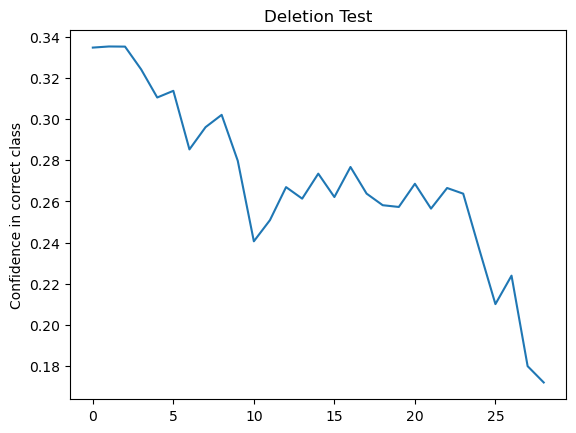

In [11]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

Text(0.5, 1.0, 'Deletion Test')

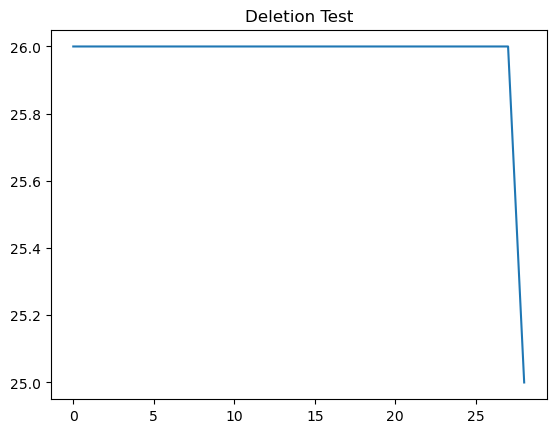

In [12]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from cub_eval import robustness_test

robustness_score_list = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'IG', input_tensor, ig.attribute)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))


Robustness score: 0.0736807100392263
Robustness score: 0.11531677613624866
Robustness score: 0.12826114270207672
Robustness score: 0.03498077064201496
Average robustness score:  0.08805984987989166


## SPARSITY AND SPATIAL COHERENCE

In [14]:
from cub_eval import calculate_gini_index, calculate_spatial_coherence
from skimage.measure import label

gini_list = []
coherence_list = []
for heatmap in heatmaps:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.8272821570112582
Spatial Coherence: 0.0419082545508176
Gini Index: 0.8094417885185511
Spatial Coherence: 0.1295124305822941
Gini Index: 0.7785219067647124
Spatial Coherence: 0.2374326692753416
Gini Index: 0.8116432632078335
Spatial Coherence: 0.18287448445637586
Average Gini Index:  0.8067222788755888
Average Spatial Coherence:  0.1479319597162073


## INTRA CLASS CONSISTENCY

In [18]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]


Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg
Classe Predita: 62 (Prob: 0.8156)


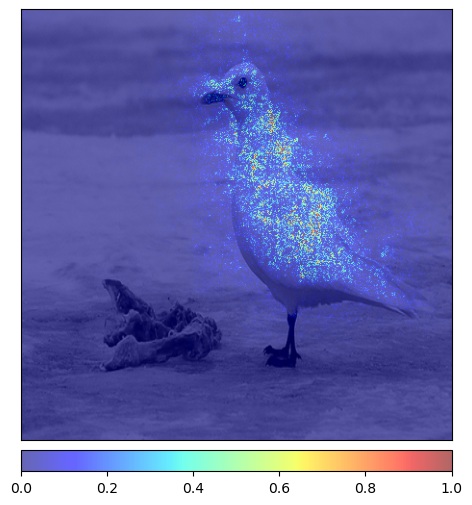

Explicação salva em: ../../out\ig_Ivory_Gull_0037_49068.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg
Classe Predita: 62 (Prob: 0.5714)


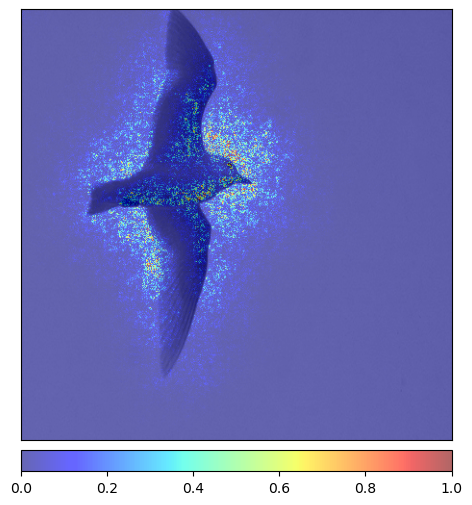

Explicação salva em: ../../out\ig_Ivory_Gull_0118_49191.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg
Classe Predita: 62 (Prob: 0.9629)


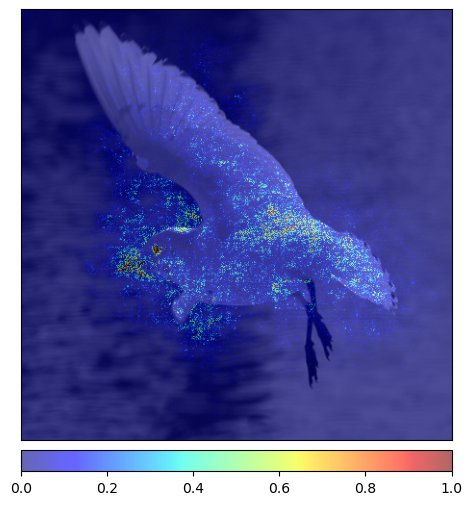

Explicação salva em: ../../out\ig_Ivory_Gull_0077_49051.jpg

Imagem: ../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg
Classe Predita: 62 (Prob: 0.9403)


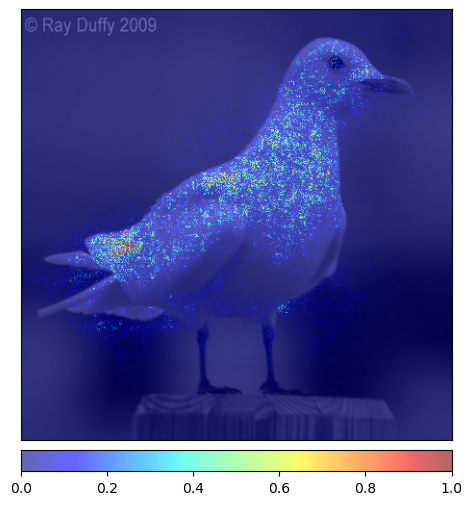

Explicação salva em: ../../out\ig_Ivory_Gull_0099_49218.jpg


In [ ]:
ig = IntegratedGradients(model)
heatmaps = []
for img_path in test_images:

    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()

    print(f"\nImagem: {img_path}")
    print(f"Classe Predita: {pred_class_idx} (Prob: {pred_class_prob:.4f})")

    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))
    
    img_np = np.array(image.resize((448, 448))) / 255.0

   
    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="absolute_value", 
        show_colorbar=True,
        use_pyplot=True,
        cmap="jet",            
        outlier_perc=2,        
        alpha_overlay=0.6      
    )
    

    out_filename = f"ig_{os.path.basename(img_path)}"
    save_path = os.path.join(Config.OUTPUT_DIR, out_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Explicação salva em: {save_path}")
    
    plt.close()

    heatmap = np.mean(np.abs(attr_np), axis=2)
    heatmaps.append(heatmap)


In [16]:
from cub_eval import intraclass_consistency

consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.22720692789759875
